<a href="https://colab.research.google.com/github/YuliaLoburets/A-B-test_project/blob/main/A_B_Testing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated successfully')

Authenticated successfully


In [53]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import matplotlib.ticker as ticker
warnings.filterwarnings('ignore')

In [54]:

# ── CONFIG ──────────────────────────────────────────────
PROJECT_ID = 'testproject-470912'
DATASET    = 'pricing_experiment.car_usage_data'
# ────────────────────────────────────────────────────────

client = bigquery.Client(project=PROJECT_ID)

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']

def run_query(sql):
    """Run a BigQuery SQL query and return a pandas DataFrame."""
    return client.query(sql).to_dataframe()

print('Setup complete')

Setup complete


In [55]:
desired_width=320
pd.set_option('display.width', desired_width)
pd.set_option('display.max_columns', 20)

In [56]:
overview_query = f"""
SELECT *
FROM `{DATASET}`
"""
overview = run_query(overview_query)
overview.head(10)

,rent_id,user_id,start_dt,end_dt,cost,type_,car_class,flag_ftr
0,7266017499955140000,6341823040309490000,48:26.0,26:57.0,-1250.0,Short rent,Comfort,0
1,2694397645716480000,7486465028761380000,03:01.0,39:21.0,0.0,Long rent,Comfort,1
2,3822972942289750000,8733503588685500000,02:09.0,40:36.0,0.0,Long rent,Comfort,1
3,16633516079053600,6696377725323650000,47:49.0,05:03.0,0.0,Long rent,Comfort,1
4,578314446309090000,6362516843803520000,56:10.0,03:06.0,0.0,Short rent,Comfort,1
5,3051109028683770000,7307266763897690000,30:47.0,24:34.0,0.0,Long rent,Comfort,1
6,8574504883423410000,9192171768180830000,43:48.0,50:42.0,0.0,Long rent,Comfort,-1
7,8764416851180600000,9089247902658340000,23:58.0,25:43.0,0.0,Long rent,Comfort,-1
8,9175531106799080000,5412519947454960000,08:43.0,42:16.0,0.0,Long rent,Comfort,1
9,8154826257376720000,3727813601910090000,28:06.0,09:57.0,0.0,Long rent,Comfort,-1


In [57]:
overview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316469 entries, 0 to 316468
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   rent_id    316469 non-null  Int64  
 1   user_id    316469 non-null  Int64  
 2   start_dt   316469 non-null  object 
 3   end_dt     316469 non-null  object 
 4   cost       316469 non-null  float64
 5   type_      316469 non-null  object 
 6   car_class  316469 non-null  object 
 7   flag_ftr   316469 non-null  Int64  
dtypes: Int64(3), float64(1), object(4)
memory usage: 20.2+ MB


In [58]:
overview['cost'].describe()

,cost
count,316469.000000
mean,1663.399864
std,2302.953421
min,-1250.000000
25%,731.250000
50%,1239.583333
75%,1956.250000
max,425839.583300


In [59]:
dup = overview.groupby('user_id').agg(duplicates=('user_id','count')).reset_index()
dup.sort_values(by='duplicates', ascending=False)

,user_id,duplicates
6447,1615995789360480000,791
27832,6993220522717430000,367
35606,8998651449142730000,358
19082,4804034955114900000,319
7388,1845710661862130000,318
...,...,...
12208,3051291031027250000,1
12207,3051112852452310000,1
25,6314533619391700,1
14,2724197947325470,1


In [60]:
user_overview = overview.groupby('user_id').agg(rentals=('rent_id', 'count'), total_cost = ('cost', 'sum'), median_cost = ('cost', 'median'), mean_cost = ('cost', 'mean'), max_cost = ('cost', 'max'), min_cost = ('cost','min')).round(1)
user_overview.sort_values(by='rentals', ascending=False)

,rentals,total_cost,median_cost,mean_cost,max_cost,min_cost
user_id,,,,,,
1615995789360480000,791,41989.6,31.2,53.1,433.3,0.0
6993220522717430000,367,298393.8,785.4,813.1,3266.7,39.6
8998651449142730000,358,105414.6,155.2,294.5,1420.8,-308.3
4804034955114900000,319,273183.3,658.3,856.4,6843.8,0.0
1845710661862130000,318,212731.2,85.4,669.0,25908.3,0.0
...,...,...,...,...,...,...
3051291031027250000,1,550.0,550.0,550.0,550.0,550.0
3051112852452310000,1,295.8,295.8,295.8,295.8,295.8
6314533619391700,1,4268.8,4268.8,4268.8,4268.8,4268.8


In [61]:
user_overview.describe()

,rentals,total_cost,median_cost,mean_cost,max_cost,min_cost
count,36484.0,3.648400e+04,36484.000000,36484.000000,36484.000000,36484.000000
mean,8.674186,1.442864e+04,1595.555811,1744.385013,3214.898616,982.643364
std,15.086891,2.981754e+04,1784.914532,2068.292185,4800.842231,1613.071858
min,1.0,-5.229000e+02,-261.500000,-261.500000,-206.200000,-1250.000000
25%,1.0,2.008300e+03,866.700000,969.600000,1350.000000,314.600000
50%,3.0,5.450000e+03,1293.800000,1408.300000,2216.700000,658.300000
75%,9.0,1.521880e+04,1856.200000,2008.300000,3673.425000,1204.200000
max,791.0,1.889585e+06,93770.800000,157874.300000,425839.600000,93770.800000


In [62]:
round(overview.query('cost <=0').shape[0]/overview.shape[0]*100,1)

2.4

Only 2.4% of transactions have non-positive values. The presence of zero and negative transactions suggests promotional activities, refunds, cancellations, or accounting adjustments. Since their business meaning is not documented and the share is relatively small, they were retained in the exploratory analysis and flagged as a potential area for further business validation

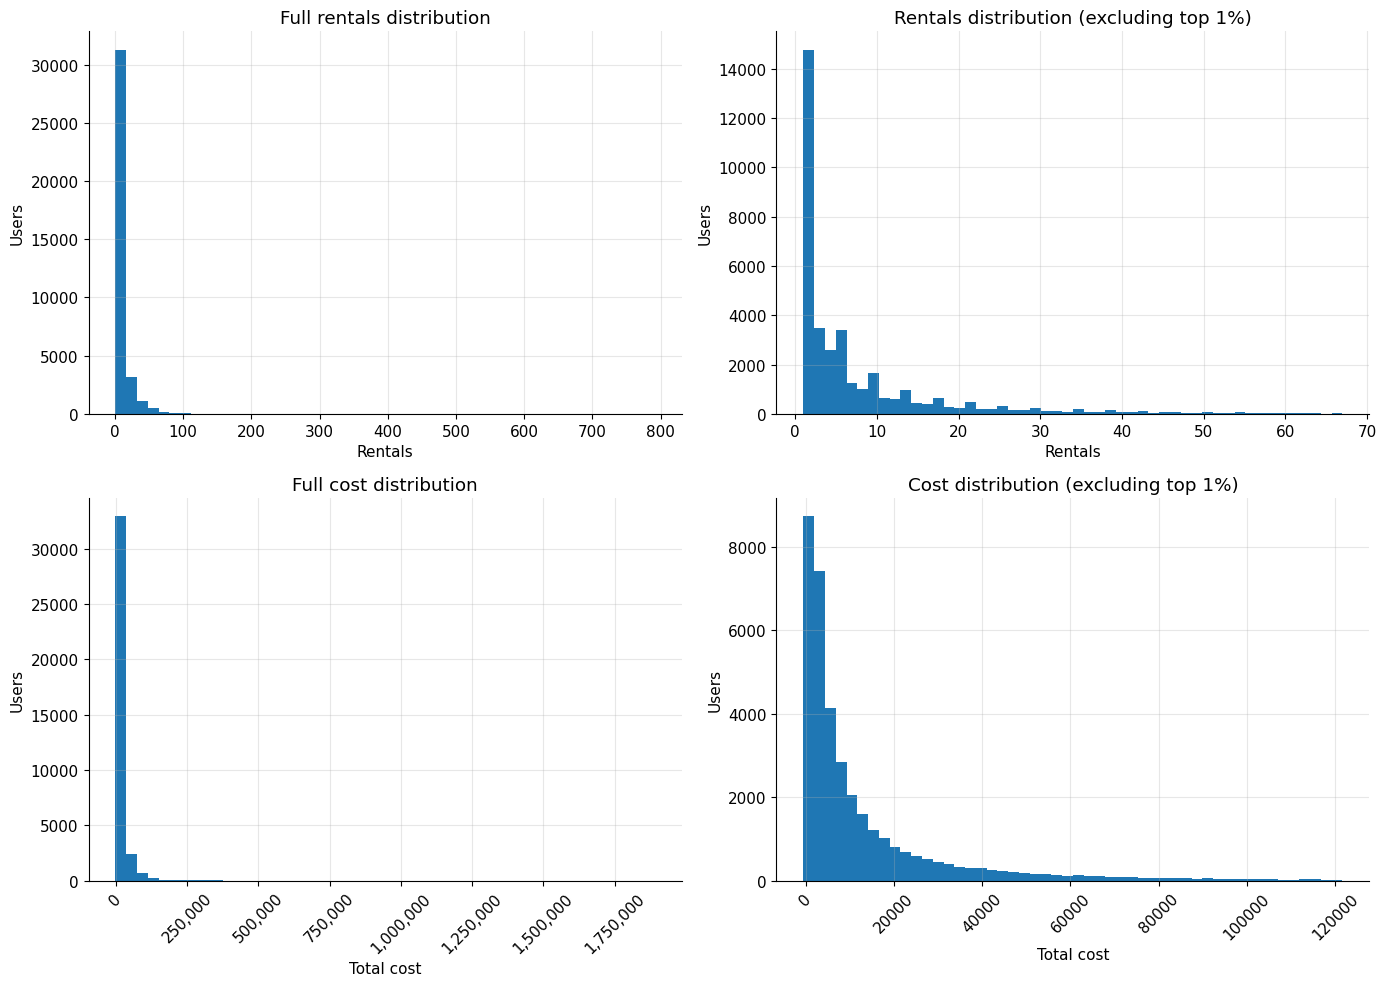

In [63]:
plt.close('all')
q99_rentals = user_overview['rentals'].quantile(0.99)
rentals_less_q99 = user_overview.query('rentals < @q99_rentals')

q99_costs = user_overview['total_cost'].quantile(0.99)
cost_less_q99 =  user_overview.query('total_cost < @q99_costs')

fig, axes = plt.subplots(2,2, figsize=(14,10))
axes[0,0].hist(user_overview['rentals'], bins=50)
axes[0,0].set_title('Full rentals distribution')
axes[0,0].set_xlabel('Rentals')
axes[0,0].set_ylabel('Users')

axes[0,1].hist(rentals_less_q99['rentals'], bins=50)
axes[0,1].set_title('Rentals distribution (excluding top 1%)')
axes[0,1].set_xlabel('Rentals')
axes[0,1].set_ylabel('Users')

axes[1,0].hist(user_overview['total_cost'], bins=50)
axes[1,0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_title('Full cost distribution')
axes[1,0].set_xlabel('Total cost')
axes[1,0].set_ylabel('Users')

axes[1,1].hist(cost_less_q99['total_cost'], bins=50)
axes[1,1].set_title('Cost distribution (excluding top 1%)')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xlabel('Total cost')
axes[1,1].set_ylabel('Users')

plt.tight_layout()
plt.show()

Both rental frequency and total spending are highly right-skewed. Most users have a small number of rentals and relatively low total spend, while a small group of highly active users generates disproportionately high activity and revenue. Therefore, customer segmentation by usage frequency and spending level is necessary before designing a pricing experiment.

##Customer Segmentation Analysis

In [67]:
user_overview[['total_cost', 'rentals']].quantile([0.1,0.5,0.75,0.95])

,total_cost,rentals
0.10,877.10,1.0
0.50,5450.00,3.0
0.75,15218.80,9.0
0.95,57453.53,35.0


In [75]:
user_overview['frequency_segment'] = pd.cut(user_overview['rentals'], bins=[0, 3, 9, 35, np.inf], labels = ['Low', 'Medium', 'High','Power Users'])
user_overview['cost_segment'] = pd.cut(user_overview['total_cost'], bins=[-np.inf, 5450, 15218.8, 57453.5, np.inf], labels = ['Low', 'Medium', 'High','Power Users'])

In [76]:
user_overview.groupby('frequency_segment').agg(avg_rentals=('rentals','mean'),
                                               median_cost = ('total_cost','median'),
                                               mean_cost = ('total_cost','mean'),
                                               users = ('rentals','count'),
                                               avg_ticket=('mean_cost','mean'),
                                               median_ticket=('mean_cost','median')).round(1)

,avg_rentals,median_cost,mean_cost,users,avg_ticket,median_ticket
frequency_segment,,,,,,
Low,1.7,2064.6,3007.7,18284,1799.5,1339.2
Medium,5.9,8258.3,10043.9,9174,1717.4,1451.4
High,17.9,24479.2,29713.4,7292,1662.9,1457.8
Power Users,58.4,75302.1,93777.1,1734,1649.0,1436.1


In [77]:
user_overview.groupby('cost_segment').agg(users = ('rentals','count'),
                                          avg_rentals=('rentals','mean'),
                                          median_cost = ('total_cost','median'),
                                          mean_cost = ('total_cost','mean'),
                                          avg_ticket=('mean_cost','mean'),
                                          median_ticket=('mean_cost','median')).round(1)

,users,avg_rentals,median_cost,mean_cost,avg_ticket,median_ticket
cost_segment,,,,,,
Low,18243,2.0,2008.3,2255.0,1273.0,1114.6
Medium,9121,6.2,8906.2,9363.3,2060.5,1605.8
High,7295,17.9,25814.6,28903.1,2257.1,1672.2
Power Users,1825,50.9,82389.6,103575.7,2827.1,1956.6


<Axes: >

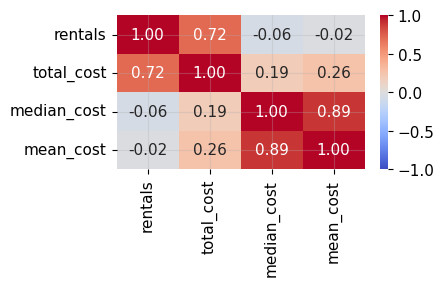

In [78]:
corr = user_overview[['rentals','total_cost','median_cost','mean_cost']].corr()
plt.figure(figsize =(4,2))
sns.heatmap(corr, annot=True, cmap='coolwarm',  fmt='.2f', vmin=-1, vmax=1)

In [79]:
round(pd.crosstab(user_overview['frequency_segment'], user_overview['cost_segment'], normalize='index')*100,1)

cost_segment,Low,Medium,High,Power Users
frequency_segment,,,,
Low,87.5,11.4,1.1,0.0
Medium,24.0,61.4,14.2,0.4
High,0.7,19.2,72.8,7.3
Power Users,0.0,0.1,27.7,72.3


The analysis revealed a strong positive relationship between rental frequency (`rentals`) and total customer spending (`total_cost`), with a correlation coefficient of **0.72**. This is expected, as total spending is directly driven by the number and value of completed rentals.

Users were segmented by rental frequency:

* **Low Frequency:** 1–3 rentals
* **Medium Frequency:** 4–9 rentals
* **High Frequency:** 10–35 rentals
* **Power Users:** 36+ rentals

The results show a strong association between usage frequency and spending. For example, **87.5%** of low-frequency users belong to the low-spending segment, while **72.8%** of high-frequency users and **72.3%** of Power Users belong to the highest spending segments. This confirms that rental frequency is a key driver of customer value.

However, the average transaction value remains relatively stable across all frequency segments, ranging from **1.6k to 1.8k**. This suggests that highly active users generate more revenue primarily through a larger number of rentals rather than more expensive transactions.

In contrast, average ticket size increases significantly across spending segments, from **1.3k** in the low-spending segment to **2.8k** in the highest-spending segment. This indicates the presence of a distinct customer group that contributes more revenue through higher-value rentals.

Overall, customer value appears to be driven by two behavioral patterns:

1. **Frequency-driven value** -  customers generate more revenue by renting more often.
2. **Transaction-value-driven value** - customers generate more revenue by choosing higher-priced rentals.

These findings are important for the pricing experiment design. Rental frequency is a suitable variable for user stratification, while spending segments should be used for post-experiment analysis to evaluate differences in price sensitivity across customer groups.


In [81]:
car_stats = overview.groupby('car_class').agg(rentals=('rent_id','count'), users=('user_id','nunique'),total_cost=('cost','sum'),mean_cost=('cost','mean'), median_cost=('cost','median')).round(1)
car_stats['']

,rentals,users,total_cost,mean_cost,median_cost
car_class,,,,,
Comfort,40718,14878,94895904.2,2330.6,1572.9
Econom,275751,34273,431518587.5,1564.9,1202.1
